# Import necessary libraries and packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import train_test_split
from sklearn.model_selection import train_test_split

# Preprocessing
# StandardScaler, OneHotEncoder, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# import LogisticRegression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# import XGBClassifier model
from xgboost import XGBClassifier

# classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Optimization  
from sklearn.model_selection import RandomizedSearchCV

# Read Datasets

In [2]:
fill_path = "/kaggle/input/delay-flights/clean_data.csv"

MainDF = pd.read_csv(fill_path)
MainDF.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,ArrTime,AirTime,...,DistanceGroup,DivAirportLandings,Delay,Delayed,Dep_mins,CRSDep_mins,DepDelay,Arr_mins,CRSArr_mins,ArrDelay
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1202.0,1157.0,1256.0,38.0,...,1.0,0.0,0.0,0,717.0,722,0.0,776.0,784,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1202.0,1157.0,1258.0,36.0,...,1.0,0.0,0.0,0,717.0,722,0.0,778.0,784,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1202.0,1153.0,1302.0,40.0,...,1.0,0.0,7.0,0,713.0,722,0.0,782.0,784,0.0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1202.0,1150.0,1253.0,35.0,...,1.0,0.0,1.0,0,710.0,722,0.0,773.0,784,0.0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,0.0,0.0,1400.0,1355.0,1459.0,36.0,...,1.0,0.0,4.0,0,835.0,840,0.0,899.0,900,0.0


In [3]:
MainDF.shape

(5598897, 41)

In [4]:
MainDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5598897 entries, 0 to 5598896
Data columns (total 41 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   FlightDate                               object 
 1   Airline                                  object 
 2   Origin                                   object 
 3   Dest                                     object 
 4   Cancelled                                float64
 5   Diverted                                 float64
 6   CRSDepTime                               float64
 7   DepTime                                  float64
 8   ArrTime                                  float64
 9   AirTime                                  float64
 10  CRSElapsedTime                           float64
 11  ActualElapsedTime                        float64
 12  Distance                                 float64
 13  Quarter                                  float64
 14  Month             

In [5]:
MainDF["Delayed"].value_counts()

Delayed
0    5232700
1     366197
Name: count, dtype: int64

In [6]:
MainDF.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'ArrTime', 'AirTime', 'CRSElapsedTime',
       'ActualElapsedTime', 'Distance', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'Operating_Airline',
       'OriginAirportID', 'OriginCityName', 'OriginState', 'OriginStateName',
       'DestAirportID', 'DestCityName', 'DestState', 'DestStateName',
       'DepTimeBlk', 'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup',
       'DivAirportLandings', 'Delay', 'Delayed', 'Dep_mins', 'CRSDep_mins',
       'DepDelay', 'Arr_mins', 'CRSArr_mins', 'ArrDelay'],
      dtype='object')

# Balance the data

In [7]:
# balance data
#1. Separate Minority and Majority Classes (DataFrames)
df_majority = MainDF[MainDF["Delayed"] == 0]
df_minority = MainDF[MainDF["Delayed"] == 1]

minority_size = len(df_minority) # OUR CHOICE
# 2. Undersample the Majority Class (sampling rows from the DataFrame)
df_majority_undersampled = df_majority.sample(
    n= (minority_size - 5000),
    replace=False,
    random_state=42
)

# 3. Combine the Undersampled Majority with the Minority Class
delay_df_balanced = pd.concat([df_majority_undersampled, df_minority]) # the new df with all feature but balanced delayed

In [8]:
delay_df_balanced["Delayed"].value_counts()

Delayed
1    366197
0    361197
Name: count, dtype: int64

In [9]:
delay_df_balanced.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'ArrTime', 'AirTime', 'CRSElapsedTime',
       'ActualElapsedTime', 'Distance', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'Operating_Airline',
       'OriginAirportID', 'OriginCityName', 'OriginState', 'OriginStateName',
       'DestAirportID', 'DestCityName', 'DestState', 'DestStateName',
       'DepTimeBlk', 'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup',
       'DivAirportLandings', 'Delay', 'Delayed', 'Dep_mins', 'CRSDep_mins',
       'DepDelay', 'Arr_mins', 'CRSArr_mins', 'ArrDelay'],
      dtype='object')

# Feature selection:

In [10]:
#calssification model for is delayed AND REGRESSION TARGET
SELECTED_FEATURES = ['Airline','DepTime','CRSElapsedTime','Month','DayofMonth',
 'DayOfWeek','DestStateName','DistanceGroup','DepDelay', 'Delay', 'Delayed']

delay_df_balanced = delay_df_balanced[SELECTED_FEATURES]

# Create the feature matrix (X) and the target vector (y).
x_class = delay_df_balanced.drop(['Delay', 'Delayed'], axis=1)
y_class = delay_df_balanced['Delayed']


x_reg = delay_df_balanced.drop(['Delay', 'Delayed'], axis=1)
y_reg = delay_df_balanced['Delay']

# Preprocessing 

In [11]:
# splitting num from categorical
numeric_features = ['DepTime','CRSElapsedTime','Month','DayofMonth',
                    'DayOfWeek','DistanceGroup','DepDelay']

categorical_features = ['Airline','DestStateName']

# Preprocessing
preprocess = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features),
                  ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)]
)

# Classify Wither it's More than 15 Minutes Delay Or Not

## Train–Validation–Test Split
The dataset was divided into training, validation, and test sets to ensure unbiased model evaluation and reliable performance assessment.

In [12]:
# Train-test split
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_class, y_class, test_size=0.2, random_state=42)

# Split Train into Train-Validation
x_train_c, x_val_c, y_train_c, y_val_c = train_test_split(
    x_train_c, y_train_c, test_size=0.25, random_state=42, stratify=y_train_c)

In [13]:
print("Train shape: ", x_train_c.shape)
print("Val shape: ", x_val_c.shape)
print("Test shape: ", x_test_c.shape)

Train shape:  (436436, 9)
Val shape:  (145479, 9)
Test shape:  (145479, 9)


## 1. classification: (Baseline model) Logistic regression model Optimization

### Logistic Regression Model Pipeline

In [14]:
# Define pipeline
log_reg_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=10000))
])

In [15]:
# Hyperparameter space FOR Logistic regression
log_reg_params = {
    'clf__C': [0.001, 0.01, 0.1, 1, 5, 10, 50],
    'clf__penalty': ['l2'],           
    'clf__solver': ['lbfgs', 'saga'], 
}

In [16]:
# Logistic regression model Optimization by RandomizedSearchCV
log_reg_search = RandomizedSearchCV(
    estimator=log_reg_pipeline,
    param_distributions=log_reg_params,
    n_iter=10,
    cv=3,
    scoring='f1',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

log_reg_search.fit(x_train_c, y_train_c)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['DepTime',
                                                                                'CRSElapsedTime',
                                                                                'Month',
                                                                                'DayofMonth',
                                                                                'DayOfWeek',
                                                                                'DistanceGroup',
                                                                                'DepDelay']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Airline',
                                                                                'DestStateName'])])),
                                             ('clf',
                                              LogisticRegression(max_iter=10000))]),
                   n_jobs=-1,
                   param_distributions={'clf__C': [0.001, 0.01, 0.1, 1, 5, 10,
                                                   50],
                                        'clf__penalty': ['l2'],
                                        'clf__solver': ['lbfgs', 'saga']},
                   random_state=42, scoring='f1', verbose=2)

In [17]:
#  Best Logistic Regression Params
print("\n Best Logistic Regression Params:")
print(log_reg_search.best_params_)


 Best Logistic Regression Params:
{'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__C': 0.001}


In [18]:
# Class predictions
log_val_preds = log_reg_search.best_estimator_.predict(x_val_c)

# Predicted probabilities for the positive class
log_val_probs = log_reg_search.best_estimator_.predict_proba(x_val_c)[:, 1]

print("\n Logistic Regression Validation Performance:")
print(classification_report(y_val_c, log_val_preds))
print("Accuracy:", accuracy_score(y_val_c, log_val_preds))
print("ROC-AUC Score:", roc_auc_score(y_val_c, log_val_probs))


 Logistic Regression Validation Performance:
              precision    recall  f1-score   support

           0       0.62      0.53      0.57     72265
           1       0.59      0.68      0.63     73214

    accuracy                           0.60    145479
   macro avg       0.61      0.60      0.60    145479
weighted avg       0.61      0.60      0.60    145479

Accuracy: 0.604623347699668
ROC-AUC Score: 0.6458426542050026


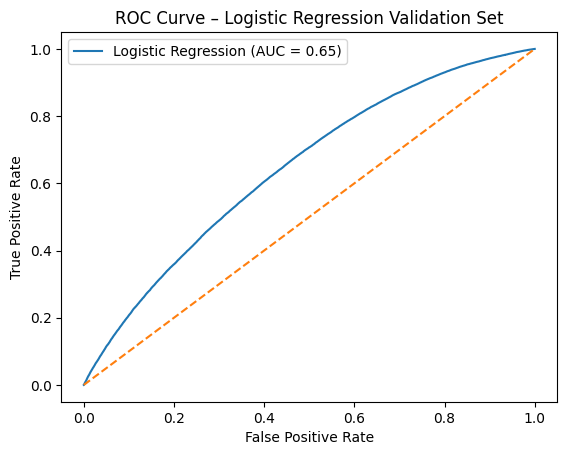

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val_c, log_val_probs)
roc_auc = roc_auc_score(y_val_c, log_val_probs)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression Validation Set")
plt.legend()
plt.show()

## 2. classification: XGBClassifier Model Optimization

 ### Pipeline for XGBClassifier Model:

In [20]:
# Define pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', XGBClassifier(
        eval_metric="logloss",
        tree_method="hist",
        random_state=42
    ))
])

### Hyperparameter Search Space (Parameter Distributions)
The following hyperparameter search space was defined for the XGBoost classifier to control model complexity, learning behavior, and regularization during the tuning process.

In [21]:
xgb_params = {
    'clf__n_estimators': [200, 300, 400, 500],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7, 10],
    'clf__min_child_weight': [1, 3, 5],
    'clf__gamma': [0, 0.1, 0.3],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'clf__reg_alpha': [0, 0.01, 0.1, 1],  # L1
    'clf__reg_lambda': [0.5, 1.0, 2.0]    # L2
}

#### Description of Hyperparameters:

* n_estimators: Number of boosting trees. Larger values improve learning capacity but increase training time and overfitting risk.

* learning_rate: Controls how much each tree contributes to the final model. Smaller values lead to more stable learning but require more trees.

* max_depth: Maximum depth of each decision tree, determining model complexity.

* min_child_weight: Minimum sum of instance weights needed in a child node. Higher values make the model more conservative.

* gamma: Minimum loss reduction required to make a split. Larger values reduce unnecessary splits and help prevent overfitting.

* subsample: Fraction of training samples used to build each tree, improving generalization.

* colsample_bytree: Fraction of features randomly selected for each tree, reducing feature correlation.

* reg_alpha: L1 regularization term that encourages sparsity and reduces overfitting.

* reg_lambda: L2 regularization term that penalizes large weights and stabilizes the model.

Purpose:

This hyperparameter search space enables efficient optimization of the XGBoost model by balancing predictive performance, training efficiency, and generalization ability.

### Hyperparameter Tuning Using RandomizedSearchCV

To optimize the performance of the XGBoost classifier, RandomizedSearchCV was used to efficiently search for the best hyperparameter combinations while handling the large dataset.

In [22]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=25,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

xgb_search.fit(x_train_c, y_train_c)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END ........clf__C=5, clf__penalty=l2, clf__solver=saga; total time= 1.8min
[CV] END ...clf__C=0.001, clf__penalty=l2, clf__solver=lbfgs; total time=   1.8s
[CV] END ...clf__C=0.001, clf__penalty=l2, clf__solver=lbfgs; total time=   1.8s
[CV] END ...clf__C=0.001, clf__penalty=l2, clf__solver=lbfgs; total time=   1.8s
[CV] END ......clf__C=50, clf__penalty=l2, clf__solver=lbfgs; total time=   7.5s
[CV] END ......clf__C=0.1, clf__penalty=l2, clf__solver=saga; total time=  23.7s
[CV] END ......clf__C=0.1, clf__penalty=l2, clf__solver=saga; total time=  33.8s
[CV] END .....clf__C=0.1, clf__penalty=l2, clf__solver=lbfgs; total time=   4.5s
[CV] END .....clf__C=0.1, clf__penalty=l2, clf__solver=lbfgs; total time=   5.4s
[CV] END .....clf__C=0.1, clf__penalty=l2, clf__solver=lbfgs; total time=   4.7s
[CV] END clf__colsample_bytree=0.6, clf__gamma=0.3, clf__learning_rate=0.05, clf__max_depth=3, clf__min_child_weight=3, clf__n_es

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['DepTime',
                                                                                'CRSElapsedTime',
                                                                                'Month',
                                                                                'DayofMonth',
                                                                                'DayOfWeek',
                                                                                'DistanceGroup',
                                                                                'DepDelay']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Airline',
                                                                                'DestStateName'])])),
                                             ('clf',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=No...
                   param_distributions={'clf__colsample_bytree': [0.6, 0.7, 0.8,
                                                                  1.0],
                                        'clf__gamma': [0, 0.1, 0.3],
                                        'clf__learning_rate': [0.01, 0.05, 0.1,
                                                               0.2],
                                        'clf__max_depth': [3, 5, 7, 10],
                                        'clf__min_child_weight': [1, 3, 5],
                                        'clf__n_estimators': [200, 300, 400,
                                                              500],
                                        'clf__reg_alpha': [0, 0.01, 0.1, 1],
                                        'clf__reg_lambda': [0.5, 1.0, 2.0],
                                        'clf__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

#### Parameter Description:

* estimator: The pipeline that includes both preprocessing steps and the XGBoost classifier.

* param_distributions: The hyperparameter search space from which random combinations are sampled.

* n_iter=25: The number of random hyperparameter combinations evaluated.

* cv=3: Three-fold cross-validation used to assess model performance.

* scoring='f1': The F1-score metric was selected as the evaluation criterion, as it provides a balanced measure between precision and recall.

* n_jobs=-1: Utilizes all available CPU cores to speed up the tuning process.

* verbose=2: Displays detailed training progress during execution.

* random_state=42: Ensures reproducibility of the results.

Purpose:

The goal of this step is to identify the optimal set of hyperparameters that maximizes the model’s F1-score while maintaining strong generalization and minimizing overfitting.

### Best Hyperparameters Selection

After completing the hyperparameter tuning process using RandomizedSearchCV, the optimal set of hyperparameters for the XGBoost classifier was extracted and displayed.

#### Explanation:

* xgb_search.best_params_:

* returns the combination of hyperparameters that achieved the highest performance based on the selected evaluation metric (F1-score) during cross-validation.

* These parameters represent the most effective configuration found within the defined hyperparameter search space.

* The selected hyperparameters are then used to train the final model for evaluation and deployment.

In [23]:
print("\n Best XGB Params:")
print(xgb_search.best_params_)


 Best XGB Params:
{'clf__subsample': 0.7, 'clf__reg_lambda': 0.5, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}


#### Explanation:

* xgb_search.best_params_: returns the combination of hyperparameters that achieved the highest performance based on the selected evaluation metric (F1-score) during cross-validation.

* These parameters represent the most effective configuration found within the defined hyperparameter search space.

* The selected hyperparameters are then used to train the final model for evaluation and deployment.


### Validation Results

After identifying the optimal hyperparameters, the best-performing XGBoost model was evaluated on a separate validation dataset to assess its generalization performance.

Explanation:

* xgb_search.best_estimator_
Refers to the optimized pipeline containing the preprocessing steps and the XGBoost classifier configured with the best hyperparameters.

* .predict(x_val_c)
Generates class predictions for the validation dataset using the optimized model.

* classification_report
Provides detailed performance metrics, including:

    * Precision
    
    * Recall
    
    * F1-score
for each class, offering a comprehensive evaluation beyond accuracy alone.

* accuracy_score
Measures the overall proportion of correctly classified instances.

Purpose:

Evaluating the model on a validation set ensures that the optimized hyperparameters generalize well to unseen data and helps detect potential overfitting before final testing or deployment.

In [24]:
# Class predictions
xgb_val_preds = xgb_search.best_estimator_.predict(x_val_c)

# Predicted probabilities (needed for ROC-AUC)
xgb_val_probs = xgb_search.best_estimator_.predict_proba(x_val_c)[:, 1]

print("\nXGBoost Validation Performance:")
print(classification_report(y_val_c, xgb_val_preds))
print("Accuracy:", accuracy_score(y_val_c, xgb_val_preds))
print("ROC-AUC:", roc_auc_score(y_val_c, xgb_val_probs))


XGBoost Validation Performance:
              precision    recall  f1-score   support

           0       0.70      0.67      0.68     72265
           1       0.69      0.71      0.70     73214

    accuracy                           0.69    145479
   macro avg       0.69      0.69      0.69    145479
weighted avg       0.69      0.69      0.69    145479

Accuracy: 0.6905945187965273
ROC-AUC: 0.7579647804985978


### Observations

The model achieves an overall accuracy of approximately 69%, indicating reasonable predictive performance on unseen validation data.

The dataset is relatively balanced, as reflected by the similar support values for both classes.

For class 1 (Delayed flights):

Recall is 0.71, suggesting the model is effective at identifying delayed flights.

F1-score of 0.70 indicates a good balance between precision and recall, which is important for delay prediction tasks.

For class 0 (On-time flights):

Precision and recall values are slightly lower but remain comparable, indicating no strong bias toward either class.

The macro and weighted averages are consistent, confirming stable model performance across both classes.

Interpretation

These results suggest that the XGBoost model generalizes well to validation data and provides a balanced classification of delayed and on-time flights. The relatively strong recall for delayed flights makes the model suitable for operational scenarios where detecting delays is a priority.

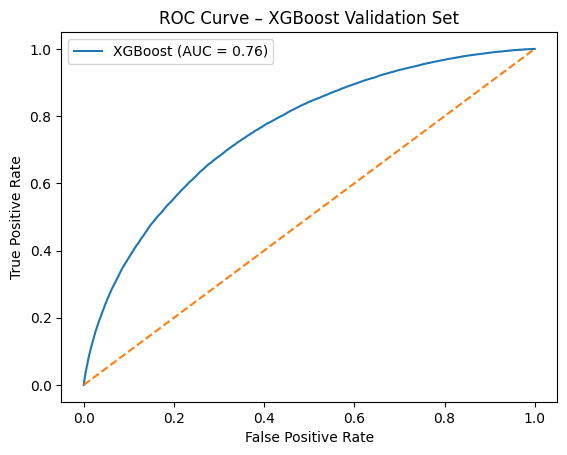

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val_c, xgb_val_probs)
roc_auc = roc_auc_score(y_val_c, xgb_val_probs)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost Validation Set")
plt.legend()
plt.show()

## Model Evaluation

In [26]:
print("\n================ FINAL TEST RESULTS ================")

# ---------- Logistic Regression ----------
print("\nLogistic Regression Test:")

log_test_preds = log_reg_search.best_estimator_.predict(x_test_c)
log_test_probs = log_reg_search.best_estimator_.predict_proba(x_test_c)[:, 1]

print(classification_report(y_test_c, log_test_preds))
print("ROC-AUC:", roc_auc_score(y_test_c, log_test_probs))


# ---------- XGBoost ----------
print("\nXGBoost Test:")

xgb_test_preds = xgb_search.best_estimator_.predict(x_test_c)
xgb_test_probs = xgb_search.best_estimator_.predict_proba(x_test_c)[:, 1]

print(classification_report(y_test_c, xgb_test_preds))
print("ROC-AUC:", roc_auc_score(y_test_c, xgb_test_probs))



================ FINAL TEST RESULTS ================

Logistic Regression Test:
              precision    recall  f1-score   support

           0       0.62      0.53      0.57     72138
           1       0.60      0.68      0.63     73341

    accuracy                           0.61    145479
   macro avg       0.61      0.61      0.60    145479
weighted avg       0.61      0.61      0.60    145479

ROC-AUC: 0.6468935110864302

XGBoost Test:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68     72138
           1       0.69      0.71      0.70     73341

    accuracy                           0.69    145479
   macro avg       0.69      0.69      0.69    145479
weighted avg       0.69      0.69      0.69    145479

ROC-AUC: 0.7567439083097469


#### Final Test Results Analysis

The final evaluation compares Logistic Regression and XGBoost models on the unseen test dataset using classification metrics and ROC-AUC.

---

**Logistic Regression – Test Performance**

> Accuracy: 0.61
> ROC-AUC: 0.65

* Precision and recall values indicate moderate performance across both classes.

* Recall for delayed flights (Class 1) is 0.68, suggesting the model can identify delays reasonably well.

* Lower precision for delayed flights indicates a higher number of false positives.

* The ROC-AUC score of 0.65 shows limited discriminative ability, reflecting the linear nature of Logistic Regression

---

**XGBoost – Test Performance**

> Accuracy: 0.69
> ROC-AUC: 0.76

* XGBoost achieves significantly higher accuracy compared to Logistic Regression.

* Balanced precision and recall across both classes indicate stable and reliable predictions.

* Recall for delayed flights reaches 0.71, improving the model’s ability to detect delays.

* A ROC-AUC of 0.76 demonstrates strong class separability, confirming that XGBoost effectively ranks delayed flights higher than on-time flights.

---

#### Model Comparison

| Metric           | Logistic Regression | XGBoost |
| ---------------- | ------------------- | ------- |
| Accuracy         | 0.61                | 0.69    |
| ROC-AUC          | 0.65                | 0.76    |
| F1-score (Delay) | 0.63                | 0.70    |

---

#### Key Observations

* XGBoost outperforms Logistic Regression across all evaluation metrics.

* The improvement in ROC-AUC confirms that XGBoost captures non-linear patterns present in flight delay data.

* Logistic Regression serves as a strong baseline but is limited in handling complex feature interactions.

* XGBoost provides better generalization and is more suitable for operational flight delay prediction.

---

#### Final Conclusion

XGBoost demonstrates superior predictive performance and discriminative capability, making it the preferred model for flight delay prediction.

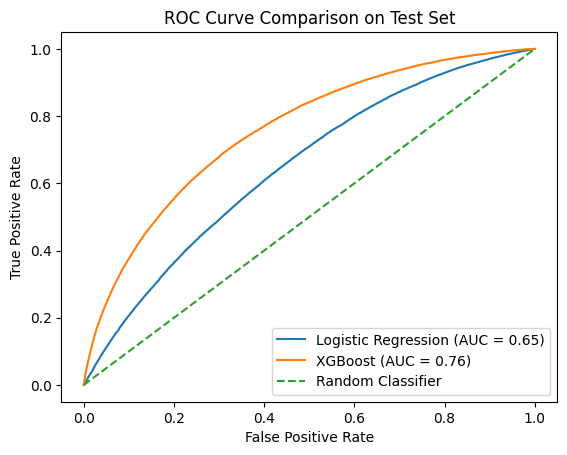

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression probabilities
log_test_probs = log_reg_search.best_estimator_.predict_proba(x_test_c)[:, 1]
log_fpr, log_tpr, _ = roc_curve(y_test_c, log_test_probs)
log_auc = roc_auc_score(y_test_c, log_test_probs)

# XGBoost probabilities
xgb_test_probs = xgb_search.best_estimator_.predict_proba(x_test_c)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_test_c, xgb_test_probs)
xgb_auc = roc_auc_score(y_test_c, xgb_test_probs)

# Plot ROC curves
plt.figure()
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison on Test Set")
plt.legend()
plt.show()


# Save Models to .pkl Files

In [28]:
import pickle

# Save XGBClassifier model
with open("xgb_classifier_model.pkl", "wb") as f:
    pickle.dump(xgb_search.best_estimator_, f)

print("Models saved successfully!")

Models saved successfully!


In [29]:
import pickle

# Load XGBClassifier model
with open("xgb_classifier_model.pkl", "rb") as f:
    xgb_loaded = pickle.load(f)

# Save Models to .jison Files

In [30]:
xgb_search.best_estimator_.named_steps['clf'].save_model(
    "xgb_model.json"
)

[CV] END ........clf__C=5, clf__penalty=l2, clf__solver=saga; total time= 1.9min
[CV] END ......clf__C=50, clf__penalty=l2, clf__solver=lbfgs; total time=   5.0s
[CV] END ......clf__C=50, clf__penalty=l2, clf__solver=lbfgs; total time=   8.0s
[CV] END ......clf__C=0.1, clf__penalty=l2, clf__solver=saga; total time=  39.1s
[CV] END ....clf__C=0.01, clf__penalty=l2, clf__solver=lbfgs; total time=   3.4s
[CV] END ....clf__C=0.001, clf__penalty=l2, clf__solver=saga; total time=   3.8s
[CV] END .......clf__C=50, clf__penalty=l2, clf__solver=saga; total time= 1.3min
[CV] END clf__colsample_bytree=0.6, clf__gamma=0.3, clf__learning_rate=0.05, clf__max_depth=3, clf__min_child_weight=3, clf__n_estimators=400, clf__reg_alpha=1, clf__reg_lambda=0.5, clf__subsample=0.7; total time=  15.2s
[CV] END clf__colsample_bytree=1.0, clf__gamma=0.3, clf__learning_rate=0.01, clf__max_depth=5, clf__min_child_weight=5, clf__n_estimators=300, clf__reg_alpha=1, clf__reg_lambda=1.0, clf__subsample=1.0; total time